# Chapitre 8 — Risques garantis (selective classification)

**🎯 Objectif :** transformer un score `P(malin)` en une **garantie de risque distribution-free** : choisir un seuil de confiance, s'abstenir en dessous, et obtenir une borne d'erreur valide sur les cas retenus — puis **décortiquer l'algorithme** qui produit cette borne, et voir ce qui est garantissable ou non.
**⏱ Durée :** ~1 min sur CPU (scores déjà calculés, aucun entraînement ni téléchargement).

Un score `P(malin)` ne dit rien sur le **risque réel** d'erreur. Le papier *Beyond Accuracy:
Controlling Broad Error Types in Selective Classification* (Emilien Jemelen, Sandrine Katsahian,
Francisco Orchard, Agathe Guilloux — INRIA & Epiconcept, AISTATS 2026) fournit des bornes
**distribution-free** : on choisit un seuil de confiance θ, on **s'abstient** sous ce seuil, et on
obtient une **garantie** (ex. « ≤ 2 % d'erreur, avec probabilité 99,5 % ») sur les cas retenus, en
échange d'une certaine **couverture** (proportion de cas non abstenus).

**Ce que le papier apporte par rapport à l'existant.** Les cadres antérieurs (SGR — *Selection
with Guaranteed Risk*) garantissent le **risque global** de mauvaise classification. Insuffisant
en médecine : on veut garantir un **type d'erreur précis** — faux positifs, faux négatifs, valeur
prédictive positive. Le papier étend donc le contrôle du risque de la perte 0/1 à **n'importe
quelle perte binaire**, et démontre de nouvelles bornes pour les **métriques conditionnelles**
sous abstention (FPR, FNR, PPV, SE, SP).

Le code est le sous-module `modules/selective-classification` (monté dans le conteneur).
**Aucun réseau ne s'entraîne dans ce chapitre** : on part d'une table de prédictions obtenue par
**inférence** avec les 5 GMIC déjà fine-tunés au chapitre 7 (détail de la provenance dans la
cellule de chargement). D'où le CPU et la minute de calcul.

> 📖 Correspondance code ↔ papier, utile pour naviguer : `B_star` = **Proposition A1**, la borne de
> risque = **Proposition 1**, la borne FPR = **Proposition 2**, la monotonicité qui autorise la
> dichotomie = **Lemme A3**, et les deux recherches de seuil = **Algorithmes 1 et 2**.

In [1]:
import sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from course_utils import selclass_dir
sys.path.insert(0, selclass_dir())   # sous-module modules/selective-classification
from python_scripts.math_utils import B_star
from python_scripts.sgp_utils import sgp_at_targets, emp_metric, DELTA

print('DELTA par défaut =', DELTA, '(soit', 100 * (1 - DELTA), '% de confiance)')

DELTA par défaut = 0.005 (soit 99.5 % de confiance)


## Décortiquer l'algorithme

Avant d'appeler `sgp_at_targets` comme une boîte noire, démontons-le. Tout l'édifice tient en
**trois briques**, et chacune répond à une question précise :

| Brique | Question | Fonction du code |
|---|---|---|
| **1. La borne binomiale** | « J'ai vu *e* erreurs sur *n* cas retenus. Quel est le pire risque compatible avec cette observation ? » | `B_star(δ, e, n)` |
| **2. Le dénominateur** | « Pour un **ratio** (FPR, FNR…), le dénominateur est lui aussi aléatoire. Comment le borner ? » | `upper_bound_denominator` + `bound` |
| **3. Le choix de θ** | « Quel seuil retenir, et avec quel algorithme de recherche ? » | `sgp_at_targets(mode=…)` |

### Brique 1 — le résultat fondamental du contrôle de risque

Tout part d'une seule inégalité. Pour un classifieur `f`, une perte `L` et un échantillon `S_n` :

$$\mathbb{P}\Big(\, R_{\mathbb{P},L}(f) \;\le\; B^{\star}_{\delta}(S_n, L, f) \,\Big) \;\ge\; 1 - \delta$$

On l'**admet** ici : la démonstration est dans le papier, on ne la refait pas. Ce qu'il faut en
lire :

| Terme | Ce que c'est |
|---|---|
| $R_{\mathbb{P},L}(f)$ | le risque **réel**, sous la vraie loi $\mathbb{P}$ des données : **inconnu**, non mesurable — c'est lui qu'on veut majorer |
| $B^{\star}_{\delta}(S_n, L, f)$ | la **borne**, calculée uniquement à partir de l'échantillon observé $S_n$ : un nombre qu'on sait produire |
| $1 - \delta$ | la probabilité que l'inégalité tienne. Avec δ = 0,005, on se trompe au pire **une fois sur 200** |

La garantie n'est donc pas « le risque vaut *x* », mais « le risque est **sous** B\*, et cette
affirmation est fiable à 1 − δ ». Elle ne suppose rien sur la distribution des données — d'où le
terme *distribution-free*.

**Reste à calculer B\*.** Par définition, c'est le pire risque encore crédible au vu de
l'observation : la valeur du risque candidat `b` pour laquelle observer *e* erreurs ou moins
devient improbable au seuil δ. Autrement dit, la **racine** de

$$F(e\,;n,b) \;=\; \sum_{k=0}^{e} \binom{n}{k} b^{k} (1-b)^{n-k} \;=\; \delta$$

Cette somme — c'est `binom_sum` dans le code — **décroît quand `b` monte** : plus le risque
supposé est mauvais, moins il est crédible de n'avoir observé que *e* erreurs. La racine est donc
unique, et on peut l'encadrer : c'est ce qui rend une **dichotomie** possible, et c'est
exactement la méthode de `B_star`. La cellule suivante montre cette racine, puis détaille les
arguments de la fonction.

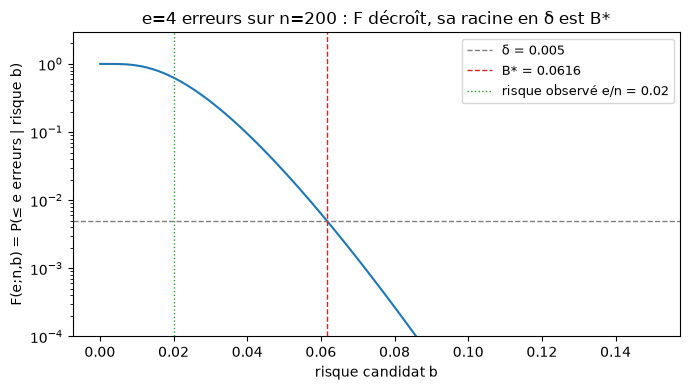

B_star(δ=0.005, e=4, n=200) = 0.0616   (risque observé : 0.0200)


In [2]:
from python_scripts.math_utils import binom_sum   # F(e;n,b), la somme que B_star inverse

# LES ARGUMENTS DE B_star(delta, e, n, b1=0, b2=1, eps=1e-5) :
#   delta  : le δ de la garantie ci-dessus (risque de se tromper qu'on s'autorise).
#   e, n   : ce qu'on a OBSERVÉ — e erreurs sur n cas retenus. Les deux seules entrées données.
#   b1, b2 : l'intervalle de recherche, [0, 1] au départ puisqu'un risque est une probabilité.
#            Ce sont les variables de la RÉCURSION, pas des réglages : à chaque appel B_star se
#            rappelle sur la moitié d'intervalle qui contient encore la racine.
#   eps    : critère d'arrêt. On renvoie le milieu dès que b2 - b1 < eps. Avec eps=1e-5 et un
#            intervalle de départ de largeur 1, cela fait 17 bissections (2^-17 < 1e-5).
e, n = 4, 200
b_star = B_star(DELTA, e, n)

b_grid = np.linspace(1e-4, 0.15, 400)
F = [binom_sum(b, e, n) for b in b_grid]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(b_grid, F, color='C0')
ax.axhline(DELTA, color='gray', ls='--', lw=1, label=f'δ = {DELTA}')
ax.axvline(b_star, color='C3', ls='--', lw=1, label=f'B* = {b_star:.4f}')
ax.axvline(e / n, color='C2', ls=':', lw=1, label=f'risque observé e/n = {e/n:.2f}')
# Échelle log en y : sinon δ=0,005 est collé à l'axe et le croisement ne se voit pas.
ax.set_yscale('log'); ax.set_ylim(bottom=1e-4)
ax.set_xlabel('risque candidat b')
ax.set_ylabel('F(e;n,b) = P(≤ e erreurs | risque b)')
ax.set_title(f'e={e} erreurs sur n={n} : F décroît, sa racine en δ est B*')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'B_star(δ={DELTA}, e={e}, n={n}) = {b_star:.4f}   (risque observé : {e/n:.4f})')


### Brique 2 — Les métriques en ratio : il faut aussi borner le dénominateur

Pour le risque **0/1**, `FP` ou `FN`, le dénominateur est le nombre de cas retenus : on le
*connaît*, `B*` suffit. Mais **FPR, FNR, PPV, SE, SP** sont des ratios conditionnés à une
sous-population :

$$\mathrm{FNR} = \frac{\#\{\text{cancers ratés}\}}{\#\{\text{cancers retenus}\}}, \qquad
  \mathrm{FPR} = \frac{\#\{\text{fausses alarmes}\}}{\#\{\text{sains retenus}\}}$$

Or ce dénominateur est lui aussi **aléatoire** : combien de cancers vont tomber dans la
sélection ? Majorer le ratio exige donc de **minorer le dénominateur** — et une minoration se
paie, elle aussi, en conservatisme. D'où la formule du code (`upper_bound_denominator`) :

$$\text{borne} = \frac{b}{d_1 - d_2}, \qquad d_1 = \widehat{\text{proportion de la classe conditionnée}}, \qquad d_2 = \frac{\sqrt{n \log(2/\delta)/2}}{|\text{sélection}|}$$

- **`d1`** = la proportion observée de la classe qui sert de dénominateur : les **cancers**
  pour FNR/SE, les **sains** pour FPR/SP (le code utilise alors `1 - d1 - d2`), les
  **prédits positifs** pour PPV.
- **`d2`** = la marge de sécurité (concentration type Hoeffding) : de combien cette proportion
  peut dévier. On retranche `d2` pour être **pessimiste** sur le dénominateur.

**C'est là que tout se joue, et c'est asymétrique.** Dans un dépistage à 2 % de prévalence :

| Métrique | `d1` | `d1 - d2` | Conséquence |
|---|---|---|---|
| **FPR** | ~0,98 (sains) | ≈ 0,98, très loin de 0 | dénominateur stable → **borne fine** |
| **FNR** | ~0,02 (cancers) | peut devenir **négatif** | borne hors [0,1] → **inutile** |

Autrement dit : ce n'est pas la métrique qui est en cause, c'est **la rareté de la classe qui
sert de dénominateur**.

> ⚠️ **Nuance importante, souvent mal dite.** On lit parfois que c'est une impossibilité
> *structurelle* — que l'on n'y pourra jamais rien. C'est faux : `d2` décroît en **1/√n**
> (numérateur en √n, dénominateur en n). Le problème est donc une question d'**échelle**, pas de
> nature. La cellule suivante calcule à partir de quel `n` la borne FNR redevient utilisable à
> 2 % de prévalence — et le chiffre est instructif.

In [3]:
PREV, COV = 0.02, 0.5      # prévalence du dépistage, et couverture (on retient 50 % des cas)

def d2_of(n, cov=COV, delta=DELTA):
    """La marge de sécurité sur le dénominateur : sqrt(n log(2/δ)/2) / |sélection|.

    |sélection| = cov*n, donc d2 ∝ sqrt(n)/n = 1/sqrt(n) : elle DÉCROÎT quand n grandit.
    C'est le point que la nuance ci-dessus corrige.
    """
    return np.sqrt(n * np.log(2 / delta) / 2) / (cov * n)

print(f"prévalence {PREV:.0%}, couverture {COV:.0%}, δ = {DELTA}")
print(f"\n{'n':>10} | {'d2':>7} | {'FNR : d1-d2':>12} | {'FPR : 1-d1-d2':>14} | borne FNR")
print('-' * 74)
for n in [1_000, 12_000, 50_000, 120_000, 500_000, 2_000_000]:
    d2 = d2_of(n)
    denom_fnr, denom_fpr = PREV - d2, 1 - PREV - d2
    # b = borne binomiale sur le nombre de cancers ratés, en supposant qu'on en rate ~30 %
    sel = int(COV * n)
    b = B_star(DELTA, int(0.3 * PREV * sel), sel)
    fnr = b / denom_fnr if denom_fnr > 0 else np.inf
    verdict = f"≤ {fnr:.2f} ✅" if 0 < fnr <= 1 else "inutile (>1) ❌"
    print(f"{n:>10d} | {d2:>7.4f} | {denom_fnr:>12.4f} | {denom_fpr:>14.4f} | {verdict}")

print("\nLecture :")
print("  • FPR : 1-d1-d2 reste proche de 0,98 dès le premier n -> borne fine tout de suite.")
print("  • FNR : d1-d2 est NÉGATIF sous ~50k, donc la borne sort de [0,1] et ne dit rien.")
print("    Elle redevient utilisable vers 1e5 échantillons — mais reste lâche (FNR ≤ 0,69).")
print("  • Donc : limite d'ÉCHELLE, pas impossibilité. Deux leviers, et le second est le moins cher :")
print("      1) beaucoup plus de données (n ~ 1e5+ à prévalence constante) ;")
print("      2) RÉÉQUILIBRER le jeu de calibration pour faire monter d1 (cf. sgp_at_targets_on_imbalanced_sets")
print("         et l'expérience FPR_control_with_resampling.ipynb du module).")

prévalence 2%, couverture 50%, δ = 0.005

         n |      d2 |  FNR : d1-d2 |  FPR : 1-d1-d2 | borne FNR
--------------------------------------------------------------------------
      1000 |  0.1095 |      -0.0895 |         0.8705 | inutile (>1) ❌
     12000 |  0.0316 |      -0.0116 |         0.9484 | inutile (>1) ❌
     50000 |  0.0155 |       0.0045 |         0.9645 | inutile (>1) ❌
    120000 |  0.0100 |       0.0100 |         0.9700 | ≤ 0.69 ✅
    500000 |  0.0049 |       0.0151 |         0.9751 | ≤ 0.42 ✅
   2000000 |  0.0024 |       0.0176 |         0.9776 | ≤ 0.35 ✅

Lecture :
  • FPR : 1-d1-d2 reste proche de 0,98 dès le premier n -> borne fine tout de suite.
  • FNR : d1-d2 est NÉGATIF sous ~50k, donc la borne sort de [0,1] et ne dit rien.
    Elle redevient utilisable vers 1e5 échantillons — mais reste lâche (FNR ≤ 0,69).
  • Donc : limite d'ÉCHELLE, pas impossibilité. Deux leviers, et le second est le moins cher :
      1) beaucoup plus de données (n ~ 1e5+ à prévalence 

### Brique 3 — Choisir θ : dichotomie ou balayage

Reste à choisir θ : le **plus bas possible** (couverture maximale) parmi ceux dont la borne
respecte la cible. C'est la **forme de la borne** qui décide de la méthode de recherche.

- **Risque 0/1, FP, FN** — la borne est **décroissante en θ** (Lemme A3) : monter le seuil ne peut
  que l'améliorer. Une **dichotomie** suffit, `mode='dicho'` (Algorithme 1).
- **FPR, FNR, PPV, SE, SP** — monter θ resserre le numérateur mais **dégrade le dénominateur**
  (brique 2). Les deux effets se combattent, la décroissance n'est plus garantie, et une
  dichotomie peut s'arrêter au mauvais endroit. D'où le **balayage** d'une grille de seuils,
  `mode='greedy'` (Algorithme 2) : on retient le premier θ qui satisfait la cible.

Une seule fonction suffit pour les deux : `sgp_at_targets(..., mode='dicho' | 'greedy')`.

On procède donc dans l'ordre : **(1)** regarder comment la borne évolue avec la couverture sur nos
données — c'est-à-dire vérifier l'hypothèse de décroissance ; **(2)** appliquer les deux
algorithmes et lire les figures.

In [4]:
from course_utils import sample_data

# ---------------------------------------------------------------------------------------
# D'OÙ VIENNENT CES DONNÉES. Ce n'est pas un jeu d'images, et aucun modèle ne s'entraîne
# ici : c'est une table de PRÉDICTIONS, produite par INFÉRENCE avec un GMIC DÉJÀ ENTRAÎNÉ.
#
#   1. ENTRAÎNEMENT (ailleurs, sur la VM GPU — ch. 7) : 5 GMIC fine-tunés depuis les poids
#      NYU, sur les 2/3 de patientes RSNA réservés à l'entraînement. Sortie = 5 checkpoints.
#   2. INFÉRENCE (ailleurs aussi) : ces checkpoints figés, en model.eval() + torch.no_grad()
#      — donc aucun gradient, aucune mise à jour de poids — appliqués UNIQUEMENT au tiers
#      de patientes restant. Les images d'entraînement ne sont même pas rechargées.
#   3. AGRÉGATION : moyenne des 5 modèles, puis moyenne des vues CC+MLO d'un même sein.
#      -> une ligne = UN SEIN (ni une image, ni une patiente).
#
# Les patientes d'entraînement n'apparaissent donc jamais dans ce fichier, et c'est la
# condition de validité de la garantie : la confiance d'un modèle sur ses propres données
# d'entraînement est trop belle, elle rendrait la borne fausse.
# C'est aussi pourquoi ce chapitre tourne en une minute sur CPU : le calcul lourd a déjà eu lieu.
# ---------------------------------------------------------------------------------------
real = pd.read_csv(sample_data('gmic_ens5_nyu_sgp_set.csv'))
print(real.head(3).to_string(index=False))

# On respecte la colonne `split` plutôt que de re-tirer au hasard : ses deux moitiés sont
# disjointes AU NIVEAU PATIENT. Un tirage aléatoire ligne par ligne (= sein par sein) mettrait
# les deux seins d'une même patiente de part et d'autre, et le test flatterait la borne.
COLS_SGP = ['kappa', 'y_pred', 'y_true']   # les 3 seules colonnes que les fonctions sgp_* lisent
train = real.loc[real.split == 'cal', COLS_SGP].sort_values('kappa').reset_index(drop=True)
test = real.loc[real.split == 'test', COLS_SGP].reset_index(drop=True)

print(f"\nborne AJUSTÉE sur {len(train)} seins ({int(train.y_true.sum())} positifs), "
      f"TESTÉE sur {len(test)} seins ({int(test.y_true.sum())} positifs)")

       p    kappa  y_pred  y_true split
0.195935 0.804065       0       0   cal
0.258472 0.741528       0       0   cal
0.110107 0.889893       0       0   cal

borne AJUSTÉE sur 3972 seins (81 positifs), TESTÉE sur 3972 seins (83 positifs)


## Étape 1 — l'accuracy monte avec le seuil de softmax response

Toute l'abstention repose sur une observation simple : `kappa = max(p, 1-p)` — la *softmax
response* — sépare plutôt bien les cas faciles des cas douteux. Si on ne répond que sur les cas
dont la confiance dépasse θ, l'accuracy **sur les cas retenus** monte quand θ monte.

Elle monte, mais sur **de moins en moins de cas**. C'est le compromis accuracy ↔ couverture, et
c'est tout le sujet du chapitre.

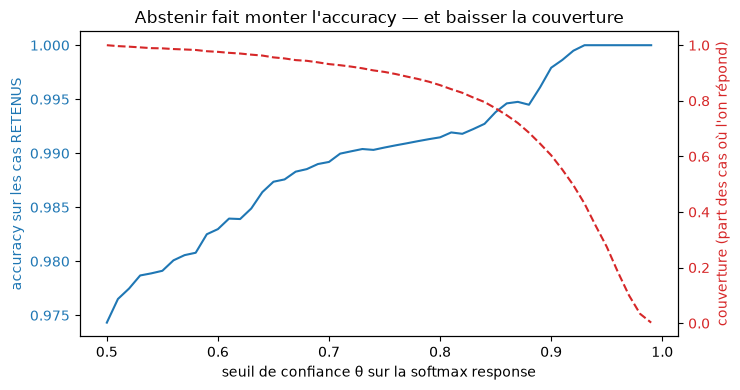

θ=0.50 ->  3972 cas retenus (100.0%), accuracy 0.9743
θ=0.80 ->  3401 cas retenus ( 85.6%), accuracy 0.9915
θ=0.90 ->  2399 cas retenus ( 60.4%), accuracy 0.9979
θ=0.99 ->     8 cas retenus (  0.2%), accuracy 1.0000


In [5]:
# emp_metric(sous-ensemble, 'standard') = risque 0/1 -> accuracy = 1 - risque.
thetas = np.linspace(0.5, 0.99, 50)
acc = [1 - emp_metric(test.loc[test.kappa >= t], 'standard') for t in thetas]
cov = [len(test.loc[test.kappa >= t]) / len(test) for t in thetas]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(thetas, acc, color='C0')
ax.set_xlabel('seuil de confiance θ sur la softmax response')
ax.set_ylabel('accuracy sur les cas RETENUS', color='C0')
ax.tick_params(axis='y', labelcolor='C0')

# Deux axes : l'accuracy ne varie que de ~2 points, la couverture de 100 points. Sur une seule
# échelle, la courbe d'accuracy serait plate.
ax2 = ax.twinx()
ax2.plot(thetas, cov, color='C3', ls='--')
ax2.set_ylabel("couverture (part des cas où l'on répond)", color='C3')
ax2.tick_params(axis='y', labelcolor='C3')

ax.set_title("Abstenir fait monter l'accuracy — et baisser la couverture")
plt.tight_layout(); plt.show()

for t in [0.5, 0.8, 0.9, 0.99]:
    sel = test.loc[test.kappa >= t]
    print(f'θ={t:.2f} -> {len(sel):5d} cas retenus ({len(sel)/len(test):6.1%}), '
          f'accuracy {1 - emp_metric(sel, "standard"):.4f}')

## Étape 2 — appliquer `sgp_at_targets`

L'étape 1 donne le compromis **mesuré**. Mais une accuracy mesurée n'est pas une garantie : à
θ = 0,99 elle vaut 100 % sur une poignée de cas, ce qui ne promet rien pour la suite (brique 1).
`sgp_at_targets` fait le passage à la garantie : il choisit θ pour que la **borne** respecte une
cible, pas pour que l'empirique fasse joli.

**Les arguments**, un par un :

| Argument | Rôle et pièges |
|---|---|
| `metric` | laquelle des 8 métriques on contrôle : `'standard'`, `'FP'`, `'FN'`, `'FPR'`, `'FNR'`, `'PPV'`, `'SE'`, `'SP'` |
| `mode` | `'dicho'` (Algorithme 1) ou `'greedy'` (Algorithme 2). **Le défaut est `'greedy'`**, et `'dicho'` n'accepte que `'standard'`/`'FP'`/`'FN'` — sur une métrique en ratio il lève une `ValueError` |
| `metric_targets` | la **liste** des cibles r\* à essayer. Une cible → une ligne de résultat → un point sur la courbe : c'est ce qui permet de tracer risque-vs-couverture en un seul appel |
| `delta` | niveau de confiance : la borne vaut avec probabilité 1 − δ. Le **diminuer** exige plus de confiance, donc **relâche** la borne |
| `theta_min`, `theta_max` | les bornes de la grille de seuils balayée — elles doivent couvrir le domaine de la fonction de confiance `kappa` |
| `k2` | nombre de seuils dans la grille du glouton (50 par défaut) |

**Deux pièges à retenir.**

1. Les défauts `theta_min=0.5, theta_max=1` collent à `kappa = max(p, 1-p)`, qui vit dans
   [0,5 ; 1] — ici `kappa` va de 0,501 à 0,9998, ça tombe juste. Mais avec une **autre** fonction
   de confiance (le module propose la variance MC-Dropout, négative, dans [−0,05 ; 0]) il faut
   changer ces bornes, sinon la grille ne rencontre aucun point et tout ressort vide.
2. Le résultat peut contenir **moins de lignes** que de cibles demandées : `sgp_at_targets` écarte
   les solutions trop loin du but (`abs(borne − r*) ≥ 0.1`) et les cibles inatteignables. Un
   DataFrame vide n'est pas un plantage — c'est un refus de conclure.

30 lignes pour 30 cibles demandées
 metric_target  metric_bound  theta_star  test_metric  test_coverage
        0.0140        0.0145      0.8047       0.0083         0.8492
        0.0203        0.0203      0.6797       0.0115         0.9441
        0.0266        0.0267      0.5859       0.0180         0.9796
        0.0328        0.0330      0.5078       0.0242         0.9977
        0.0391        0.0330      0.5078       0.0242         0.9977


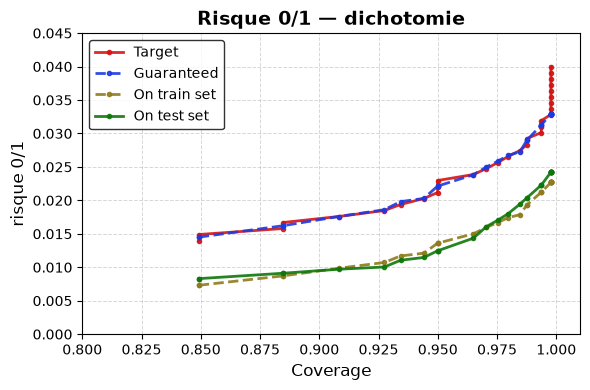

In [6]:
from python_scripts.plotting import metric_plots, lines

_, lines_cov, _, _, _ = lines()   # config de courbes du dépôt : cible / garantie / train / test
COLS = ['metric_target', 'metric_bound', 'theta_star', 'test_metric', 'test_coverage']

# Risque 0/1 : borne décroissante en θ -> dichotomie (Algorithme 1).
# theta_min/theta_max passés explicitement = domaine de kappa = max(p, 1-p).
res_std = sgp_at_targets(train, test, delta=DELTA, metric='standard', mode='dicho',
                         metric_targets=np.linspace(0.014, 0.04, 30),
                         theta_min=0.5, theta_max=1)
print(f'{len(res_std)} lignes pour 30 cibles demandées')
print(res_std[COLS].iloc[::7].round(4).to_string(index=False))

metric_plots({'SR': res_std}, metric='risque 0/1', lines_list=lines_cov,
             xlim=[0.80, 1.01], ylim=[0, 0.045], title='Risque 0/1 — dichotomie')

 metric_target  metric_bound  theta_star  test_metric  test_coverage
        0.0040        0.0037      0.7755       0.0003         0.8822
        0.0079        0.0066      0.6735       0.0022         0.9459
        0.0117        0.0114      0.5612       0.0070         0.9862
        0.0156        0.0139      0.5306       0.0083         0.9919
        0.0194        0.0174      0.5000       0.0118         1.0000


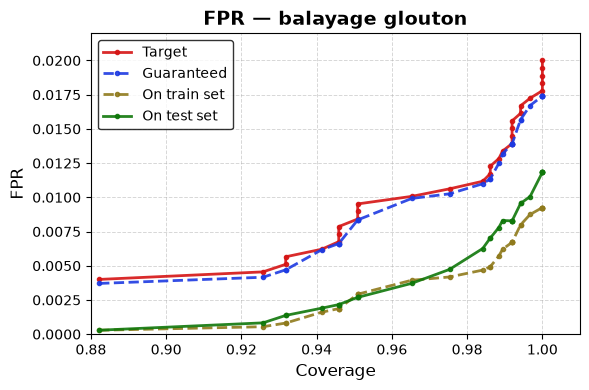


FNR : aucune cible atteignable


In [7]:
# FPR : borne non monotone en θ -> balayage glouton (Algorithme 2), k2=50 seuils.
res_fpr = sgp_at_targets(train, test, delta=DELTA, metric='FPR', mode='greedy',
                         metric_targets=np.linspace(0.004, 0.02, 30),
                         theta_min=0.5, theta_max=1, k2=50)
print(res_fpr[COLS].iloc[::7].round(4).to_string(index=False))

metric_plots({'SR': res_fpr}, metric='FPR', lines_list=lines_cov,
             xlim=[0.88, 1.01], ylim=[0, 0.022], title='FPR — balayage glouton')

# FNR : même fonction, même mode, des cibles pourtant très large (5 % à 50 %) -> DataFrame VIDE.
# Cf. piège 2 : c'est le refus de conclure, pas une erreur.
res_fnr = sgp_at_targets(train, test, delta=DELTA, metric='FNR', mode='greedy',
                         metric_targets=np.linspace(0.05, 0.5, 30))
print('\nFNR :', 'aucune cible atteignable' if res_fnr.empty else f'{len(res_fnr)} cibles')